In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvals
#from tqdm import tqdm

In [ ]:
# ----- initial parameters -----

N = 50
W1 = 2.0
W2 = 2.0
W3 = 1.0
tau = 5.0
I = 2.0
n_t = 0.0   # no noise for now


In [69]:
# ----- build the weight matrix for analyzing M-WTA -----

def str_weight_matrix(M, W1, W2, W3):
    
    W = np.full((M, M), "", dtype=object)

    # self excitation
    for i in range(M):
        W[i, i] += " + W1"

    # global inhibition among these neurons
    W += " - W2"
  
    # nearest-neighbor excitation (linear chain)
    for i in range(M - 1):
        W[i, i+1] += " + W3"
        W[i+1, i] += " + W3"
    
    return W

str_W = str_weight_matrix(2, W1, W2, W3)
str_W

array([[' + W1 - W2', ' - W2 + W3'],
       [' - W2 + W3', ' + W1 - W2']], dtype=object)

In [ ]:
# ----- build the weight matrix for analyzing M-WTA -----

def weight_matrix(M, W1, W2, W3):
    
    W = np.zeros((M, M))
    
    # self excitation
    for i in range(M):
        W[i, i] += W1 
    
    # global inhibition among these neurons
    W -= W2
    
    # nearest-neighbor excitation (linear chain)
    for i in range(M - 1):
        W[i, i+1] += W3
        W[i+1, i] += W3
    
    return W

In [ ]:
M = 3
W = weight_matrix(M, W1, W2, W3)
W

array([[ 3.,  3., -2.],
       [ 3.,  3.,  3.],
       [-2.,  3.,  3.]])

In [49]:
def check_MWTA_stability(M, W1, W2, W3, I_ext, tol=1e-12):

    W = weight_matrix(M, W1, W2, W3)

    # ----- Stablity Condition -----
    # Eigen values should be positive integers and maximum eigen value should be less than 1
    eigenvalues = np.linalg.eigvals(W)

    # Check for complex numbers
    if not np.all(np.isreal(eigenvalues)):
        return False
    
    # Check for negative numbers
    #if np.any(eigenvalues < 0):
    #    return False
        
    # Check for the upper bound (must be <= 1)
    if np.max(eigenvalues) >= 1:
        return False

    # ----- Consistency Condition -----
    # Consistency for M-WTA at steady state requires all x1,x2,...,xm > 0
    A = np.eye(M) - W
    b = I_ext * np.ones(M)

    try:
        x_s = np.linalg.solve(A, b)         
    except np.linalg.LinAlgError:
        return False 
    
    if np.min(x_s) <= 0:
        return False


    # ---- Neighboring neurons suppresion condition ----
    # the neighboring neurons of the active neurons are suppressed (total inputs to these neurons are negative) at steady state
    #for left neighboring neuron
    x_left = -W2*np.sum(x_s) + W3*x_s[0] + I_ext
    if (x_left > 0):
        return False
    #for right neighboring neuron
    x_right = -W2*np.sum(x_s) + W3*x_s[-1] + I_ext
    if (x_right > 0):
        return False
    

    return True

# check_MWTA_stability(M, W1, W2, W3, I_ext, tol=1e-12):
ok = check_MWTA_stability(1, 0, 3, 1, I)
print("stable:", ok)

stable: False


In [60]:
def test_check_MWTA_stability(M, W1, W2, W3, I_ext, tol=1e-12):

    W = weight_matrix(M, W1, W2, W3)

    # ----- Stablity Condition -----
    # Eigen values should be positive integers and maximum eigen value should be less than 1
    eigenvalues = np.linalg.eigvals(W)

    # Check for complex numbers
    if not np.all(np.isreal(eigenvalues)):
        return False
    
    # Check for negative numbers
    #if np.any(eigenvalues < 0):
    #    return False
        
    # Check for the upper bound (must be <= 1)
    if np.max(eigenvalues) >= 1:
        return False


    # ----- Consistency Condition -----
    # Consistency for M-WTA at steady state requires all x1,x2,...,xm > 0
    A = np.eye(M) - W
    b = I_ext * np.ones(M)
      
    try:
        x_s = np.linalg.solve(A, b)
        print("x_s: ", x_s)         
    except np.linalg.LinAlgError:
        return False 
    
    if np.min(x_s) <= 0:
        return False

    # ---- Neighboring neurons suppresion condition ----
    # the neighboring neurons of the active neurons are suppressed (total inputs to these neurons are negative) at steady state
    x_left = -W2*np.sum(x_s) + W3*x_s[0] + I_ext
    x_right = -W2*np.sum(x_s) + W3*x_s[-1] + I_ext
    print("x_left:", x_left)
    print("x_right:", x_right)
    
    if (x_left > 0):
        return False
    
    if (x_right > 0):
        return False

    return True

#       check_MWTA_stability(M, W1, W2, W3, I_ext, tol=1e-12):
ok = test_check_MWTA_stability(2, 0, 100, 1, I)
print("stable:", ok)

x_s:  [0.01 0.01]
x_left: 0.010000000000000009
x_right: 0.010000000000000009
stable: False


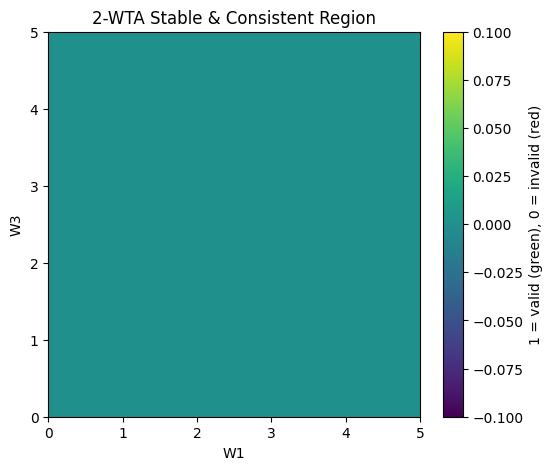

In [52]:
# Parameter grid
W1_vals = np.arange(0, 5.01, 0.01)
W3_vals = np.arange(0, 5.01, 0.01)

M = 2
W2 = 2.0
I_ext = 2.0

phase = np.zeros((len(W1_vals), len(W3_vals)))

for i, W1 in enumerate(W1_vals):
    for j, W3 in enumerate(W3_vals):
        
        M_stable = check_MWTA_stability(M, 0, i, j, I_ext)
        M1_stable = check_MWTA_stability(M+1, 0, i, j, I_ext)
        
        # M-WTA is stable and (M+1)-WTA is unstable
        phase[i, j] = int(M_stable and not M1_stable)


# plot
plt.figure(figsize=(6,5))
plt.imshow(
    phase.T,
    extent=[0,5,0,5],
    origin='lower',
    aspect='auto'
)
plt.xlabel("W1")
plt.ylabel("W3")
plt.title(f"{M}-WTA Stable & Consistent Region")
plt.colorbar(label="1 = valid (green), 0 = invalid (red)")
plt.show()